In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "CMAPSSData" / "train_FD001.txt"

### Dataset structure

Each row contains 26 columns:

- 2 identifiers: `unit_id` and `cycle`
- 3 operational settings
- 21 sensor measurements

Since the raw file has no header, the column names are defined manually.

In [3]:
df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# Rename columns
columns = (
    ["unit_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df.columns = columns

df.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Data quality

Check data types, missing values, duplicates, and basic descriptive statistics before analyzing the engine trajectories.

In [5]:
df.shape

(20631, 26)

In [6]:
df["unit_id"].nunique()

100

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [9]:
missing = df.isnull().sum()
print("Missing Values:")
print(missing[missing > 0])

if missing.sum() == 0:
    print("\nNo missing values found")

Missing Values:
Series([], dtype: int64)

No missing values found


In [10]:
df.describe()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [11]:
unique_counts = df.nunique()
constant_mask = unique_counts == 1

In [12]:
constant_columns = constant_mask[constant_mask].index.tolist()
constant_columns

['setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

### Engine trajectories

In [13]:
max_cycles = df.groupby("unit_id")["cycle"].max()
max_cycles.head()

unit_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

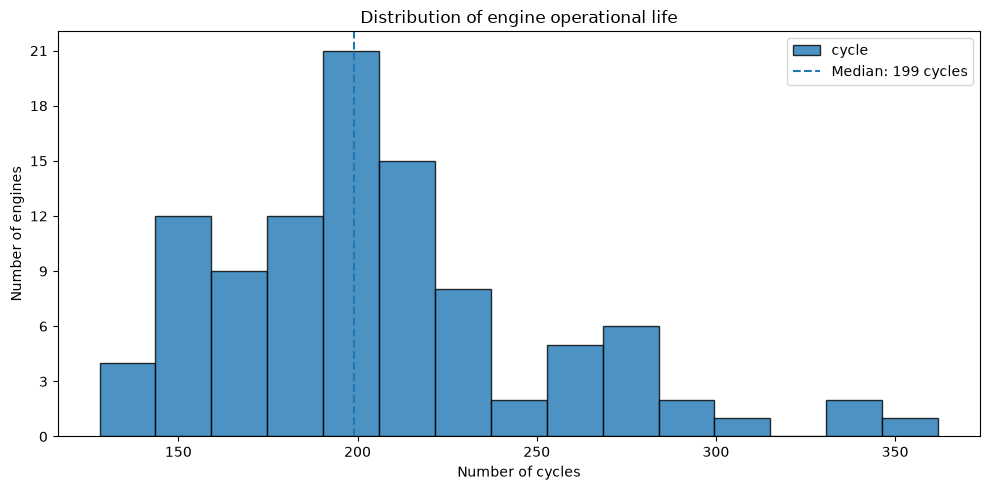

In [14]:
median_cycles = max_cycles.median()

max_cycles.plot(
    kind="hist",
    bins=15,
    figsize=(10, 5),
    edgecolor="black",
    alpha=0.8,
)

plt.axvline(
    median_cycles,
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {median_cycles:.0f} cycles",
)

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel("Number of cycles")
plt.ylabel("Number of engines")
plt.title("Distribution of engine operational life")
plt.legend()
plt.tight_layout()
plt.show()

#### Trajectory integrity

Each engine should contain one observation per operational cycle, from cycle 1 to its final recorded cycle. Before analyzing degradation patterns, we verify that there are no gaps inside these trajectories.


In [15]:
engines_with_cycle_gaps = []

for engine_id in sorted(df["unit_id"].unique()):
    engine_data = df[df["unit_id"] == engine_id]

    observed_cycles = engine_data["cycle"].sort_values().tolist()
    expected_cycles = list(range(1, engine_data["cycle"].max() + 1))

    if observed_cycles != expected_cycles:
        engines_with_cycle_gaps.append(engine_id)

if engines_with_cycle_gaps:
    print(f"Engines with cycle gaps: {engines_with_cycle_gaps}")
else:
    print("All engine trajectories have continuous cycles.")


All engine trajectories have continuous cycles.


The engines have different operational lifetimes, but each trajectory is recorded continuously. This gives us complete sequences from the beginning of observation to the final cycle available in the training data.


### Operational settings

The dataset includes three operational settings that describe the conditions under which the engines operate. FD001 represents a single operating condition, so we expect limited variation in these variables.


In [16]:
setting_columns = ["setting_1", "setting_2", "setting_3"]

setting_summary = pd.DataFrame({
    "unique_values": df[setting_columns].nunique(),
    "min": df[setting_columns].min(),
    "max": df[setting_columns].max(),
    "std": df[setting_columns].std(),
})

setting_summary


,unique_values,min,max,std
setting_1,158,-0.0087,0.0087,0.002187
setting_2,13,-0.0006,0.0006,0.000293
setting_3,1,100.0000,100.0000,0.000000


`setting_3` is constant, while `setting_1` and `setting_2` vary only slightly around zero. This is consistent with FD001 containing a single operating condition rather than multiple operating regimes.


### Sensor variability

The 21 sensor columns do not all carry the same amount of information. Before plotting trajectories, we inspect how much each sensor actually varies across the dataset.

This helps separate sensors that are constant or nearly constant from sensors whose measurements change throughout engine operation.


In [17]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

sensor_variability = pd.DataFrame({
    "unique_values": df[sensor_columns].nunique(),
    "std": df[sensor_columns].std(),
    "range": df[sensor_columns].max() - df[sensor_columns].min(),
})

sensor_variability


,unique_values,std,range
sensor_1,1,0.000000e+00,0.0000
sensor_2,310,5.000533e-01,3.3200
sensor_3,3012,6.131150e+00,45.8700
sensor_4,4051,9.000605e+00,59.2400
sensor_5,1,5.329200e-15,0.0000
sensor_6,2,1.388985e-03,0.0100
sensor_7,513,8.850923e-01,6.2100
sensor_8,53,7.098548e-02,0.6600
sensor_9,6403,2.208288e+01,222.8600
sensor_10,1,0.000000e+00,0.0000


In [18]:
constant_sensors = sensor_variability[
    sensor_variability["unique_values"] == 1
].index.tolist()

low_variability_sensors = sensor_variability[
    sensor_variability["unique_values"].between(2, 3)
].index.tolist()

variable_sensors = sensor_variability[
    sensor_variability["unique_values"] > 3
].index.tolist()

print(f"Constant sensors: {constant_sensors}")
print(f"Low-variability sensors: {low_variability_sensors}")
print(f"Sensors kept for trajectory analysis: {len(variable_sensors)}")


Constant sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Low-variability sensors: ['sensor_6']
Sensors kept for trajectory analysis: 14


The variability check explains why some sensors are not useful for visual trajectory analysis: some never change, while others take only a few distinct values. We keep them in the dataset for now, but focus the next visualization on sensors with enough variation to show an operational pattern.


### Sensor trajectories

Plotting all 100 engines at once hides individual behavior. Instead, we select three real engines with different trajectory lengths: one short-lived engine, one close to the median lifetime, and one long-lived engine.

The goal is not to claim that these three engines represent the entire fleet. They provide readable examples of how the sensor measurements evolve during complete run-to-failure trajectories.


In [19]:
short_engine = max_cycles.idxmin()
median_engine = (max_cycles - median_cycles).abs().idxmin()
long_engine = max_cycles.idxmax()

selected_engines = [short_engine, median_engine, long_engine]

selected_engine_lifetimes = max_cycles.loc[selected_engines].rename("max_cycle")
selected_engine_lifetimes


unit_id
39    128
26    199
69    362
Name: max_cycle, dtype: int64

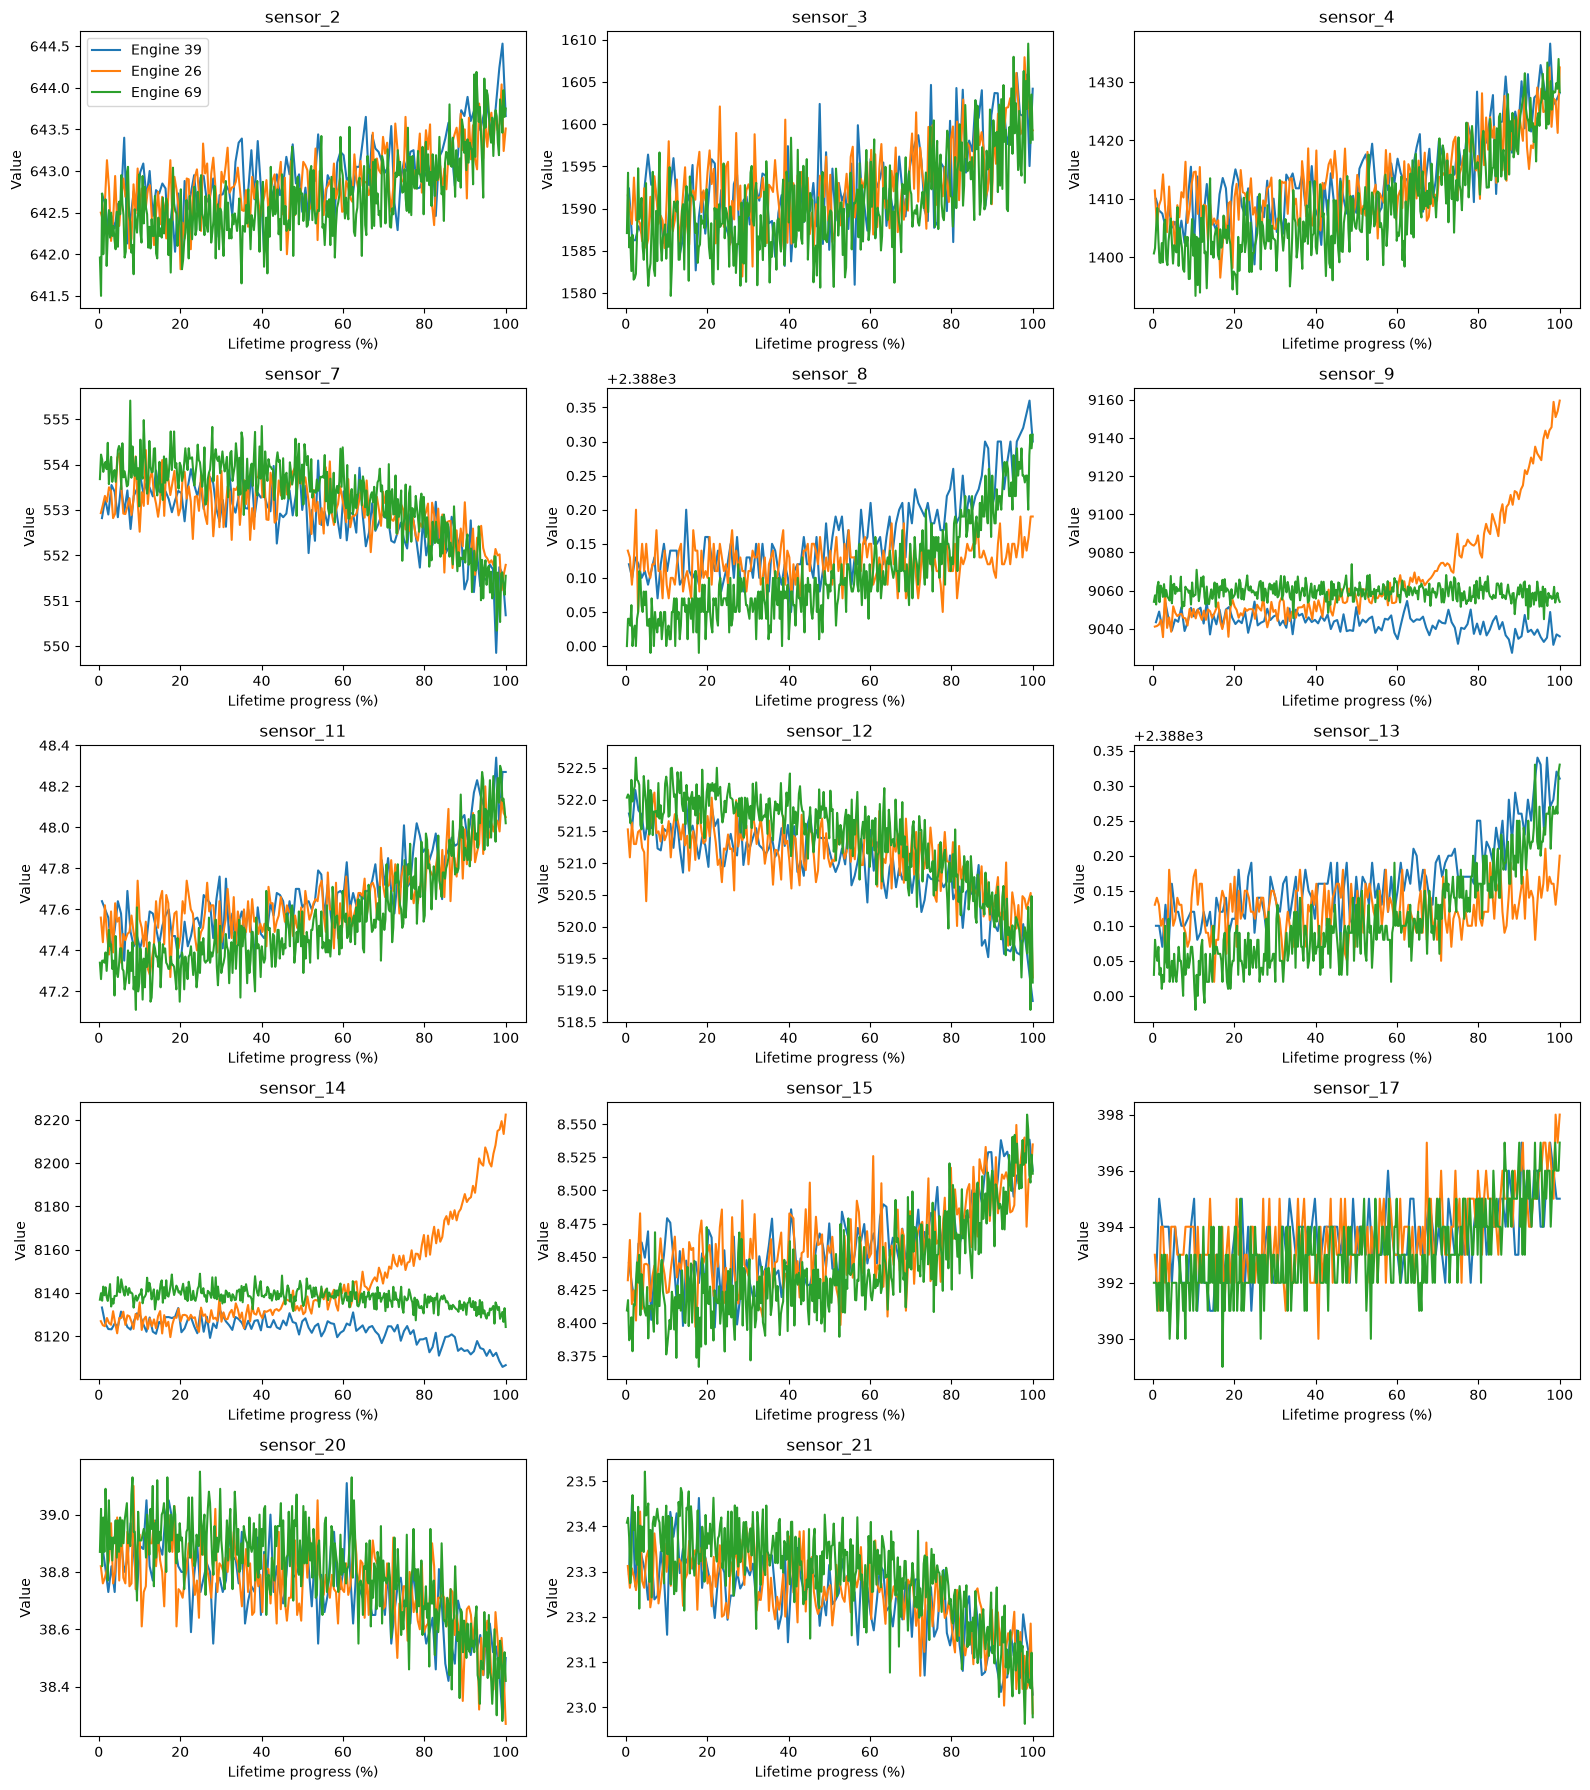

In [20]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(16, 18),
)

axes = axes.flatten()

for ax, sensor in zip(axes, variable_sensors):
    for engine_id in selected_engines:
        engine_data = df[df["unit_id"] == engine_id]
        lifetime_progress = engine_data["cycle"] / max_cycles.loc[engine_id] * 100

        ax.plot(
            lifetime_progress,
            engine_data[sensor],
            label=f"Engine {engine_id}",
        )

    ax.set_title(sensor)
    ax.set_xlabel("Lifetime progress (%)")
    ax.set_ylabel("Value")

for ax in axes[len(variable_sensors):]:
    ax.set_visible(False)

axes[0].legend()
plt.tight_layout()
plt.show()


Using lifetime progress makes engines with different lifetimes easier to compare: 0% is the beginning of the recorded trajectory and 100% is the final training cycle for that engine.

The plots show that several sensors change systematically as the engines approach the end of their trajectories, while others are noisier or follow different shapes across engines. This is the degradation signal we will later try to use for Remaining Useful Life prediction.


### Global sensor trends

The previous plots show a few complete trajectories in detail. As a complementary fleet-level view, we measure the linear relationship between each variable sensor and the raw cycle number using all training observations.

This is only a summary of direction and strength. Because engines have different lifetimes, the same cycle number does not necessarily represent the same degradation stage for every engine.


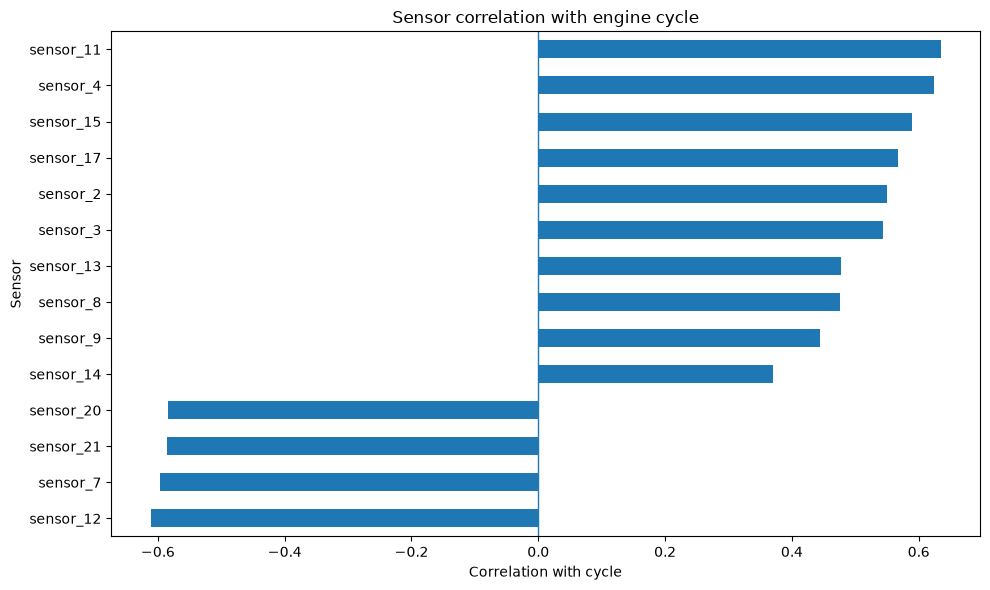

In [21]:
sensor_correlations = (
    df[variable_sensors]
    .corrwith(df["cycle"])
    .sort_values()
)

plt.figure(figsize=(10, 6))
sensor_correlations.plot(kind="barh")

plt.axvline(0, linewidth=1)
plt.xlabel("Correlation with cycle")
plt.ylabel("Sensor")
plt.title("Sensor correlation with engine cycle")
plt.tight_layout()
plt.show()


Positive values indicate sensors that tend to increase as cycle number grows; negative values indicate sensors that tend to decrease. The result supports the trajectory plots by showing that several sensor measurements have a clear directional relationship with engine operation over time.

Correlation is not used here to select model features. It only summarizes linear trends observed across the full dataset.


## Key findings

- FD001 contains 20,631 observations from 100 turbofan engine trajectories.
- Each row represents one engine at one operational cycle, with three operational settings and 21 sensor measurements.
- No missing or duplicated rows were found in the training data.
- Engine trajectories have different lengths, but their cycle sequences are continuous.
- FD001 contains a single operating condition; `setting_3` is constant and the other settings vary only slightly.
- Several sensors are constant or have very low variability, while others change substantially during engine operation.
- Readable run-to-failure examples show increasing, decreasing, and non-linear sensor patterns as engines progress through their lifetimes.
- Fleet-level correlations reinforce that several sensor measurements change with operational time, but raw cycle number is not a direct measure of degradation stage because engine lifetimes differ.

These findings give us enough understanding of the training data to move on. The next step is to define the Remaining Useful Life (RUL) target for each engine cycle and prepare the data for modeling.
